# Task 5:



# Introduction

The objective of this project is to predict whether a bank customer is likely to accept a personal loan offer. Financial institutions can use predictive analytics to identify potential customers who are more likely to respond positively to loan campaigns. This project involves exploring customer demographics and financial information, performing exploratory data analysis (EDA), and building a classification model to predict loan acceptance. The insights gained from this analysis can help banks improve marketing efficiency and target the right customer segments.


# Personal Loan Acceptance Prediction

## Problem Statement:
Predict whether a bank customer will accept a personal loan offer based on demographic and financial data.

## Objective:
Build a classification model and extract business insights from customer behavior.

## Importing Libraries

In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load Dataset

In [40]:
df = pd.read_csv("bank.csv", sep=';')

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


## Data Understanding

In [41]:
print(df.shape)
print(df.info())
print(df.describe())

(4521, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB
None
               age       balance          day     duration     campaign  \
count  4

## Data Cleaning

In [42]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


## EDA

### Age Distribution

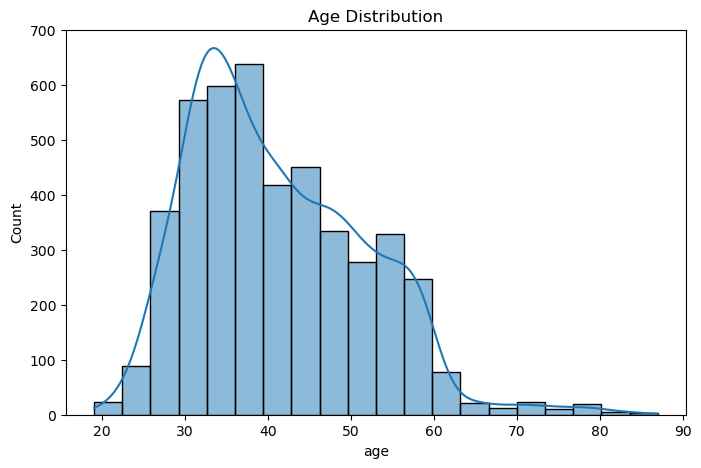

In [43]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

### Job vs Loan Acceptance

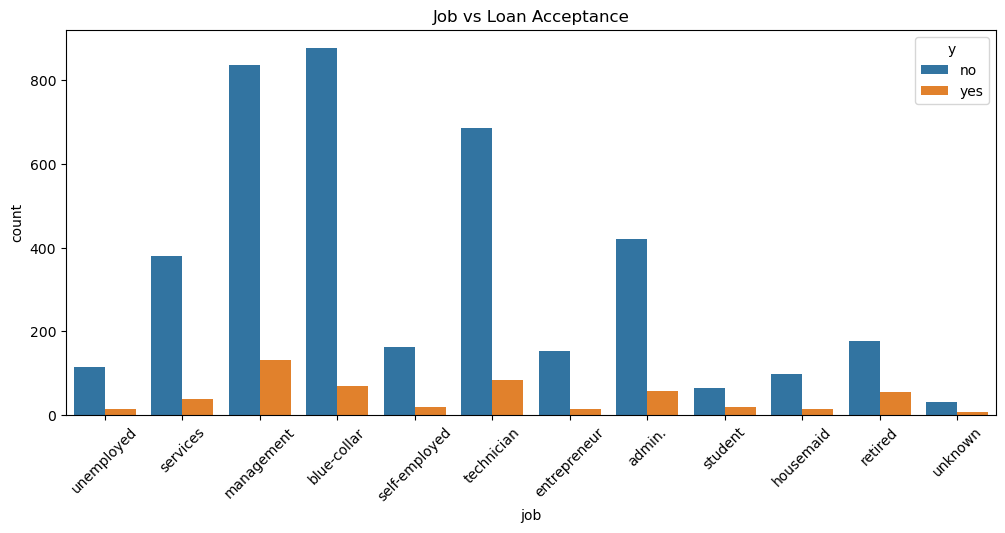

In [44]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x='job', hue='y')
plt.xticks(rotation=45)
plt.title("Job vs Loan Acceptance")
plt.show()

### Martial Status Impact

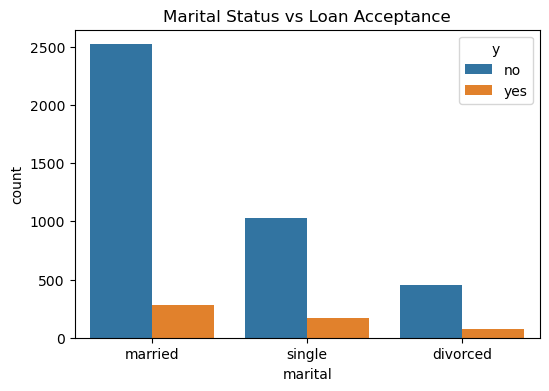

In [45]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='marital', hue='y')
plt.title("Marital Status vs Loan Acceptance")
plt.show()

### Balance vs Accepntance

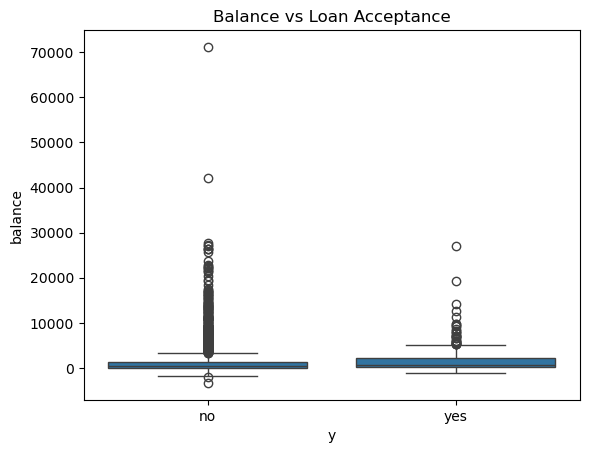

In [46]:
sns.boxplot(data=df, x='y', y='balance')
plt.title("Balance vs Loan Acceptance")
plt.show()

## Encoding

In [47]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

## Features and targets

In [48]:
X = df.drop('y', axis=1)
y = df['y']

## Train_Test_Split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Scaling

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [51]:
model = LogisticRegression(max_iter=3000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=3000)

## Predictions

In [52]:
y_pred = model.predict(X_test_scaled)

## Evaluation Matrix

### ~Accuracy

In [53]:
y_pred = model.predict(X_test_scaled)

### ~Confusing Matrix

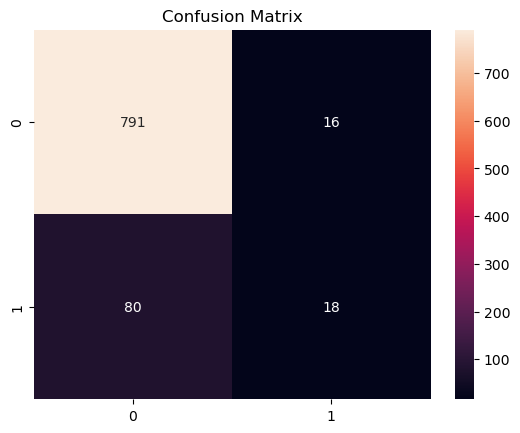

In [54]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### ~Classification Report

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       807
           1       0.53      0.18      0.27        98

    accuracy                           0.89       905
   macro avg       0.72      0.58      0.61       905
weighted avg       0.87      0.89      0.87       905



## Bussiness Insights

In [56]:
df.groupby('job')['y'].mean().sort_values(ascending=False)

job
5     0.234783
8     0.226190
11    0.184211
4     0.135191
3     0.125000
0     0.121339
6     0.109290
9     0.108073
10    0.101562
7     0.091127
2     0.089286
1     0.072939
Name: y, dtype: float64

In [57]:
df.groupby('marital')['y'].mean()

marital
0    0.145833
1    0.099035
2    0.139632
Name: y, dtype: float64

# Conclusion

The Bank Marketing dataset was explored and analyzed to understand customer behavior related to personal loan acceptance. Data preprocessing and encoding techniques were applied to prepare the dataset for machine learning. A classification model was trained and evaluated using accuracy and confusion matrix metrics. The analysis revealed that factors such as age, job type, marital status, and financial characteristics influence loan acceptance decisions. These findings can help banks design more effective marketing strategies and focus their efforts on customer groups with a higher probability of accepting loan offers.
